In [3]:
from simulate import *
from imports import *
# data, lensed_temp, unlensed_temp, phi, cn, cf, cfl, cphi, m, b, d_matrix, g, nphi = \
#         load_sim(N = 256, theta_pix = 2, uk_arcmin_t = 10, seed = None, lmax = 17000)

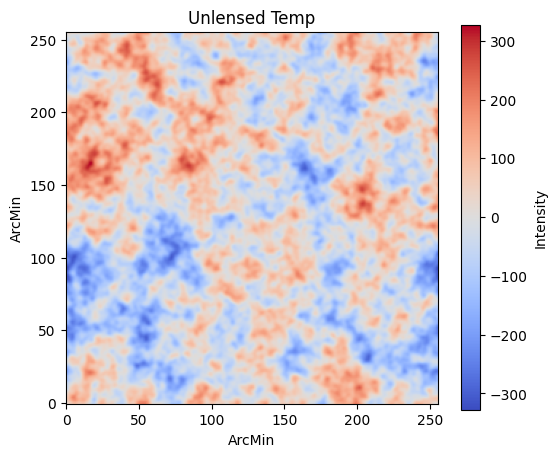

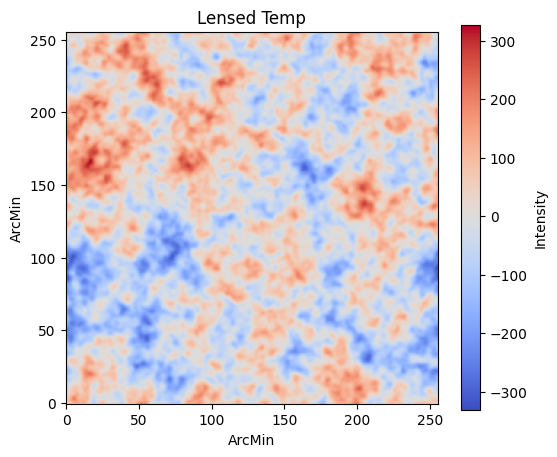

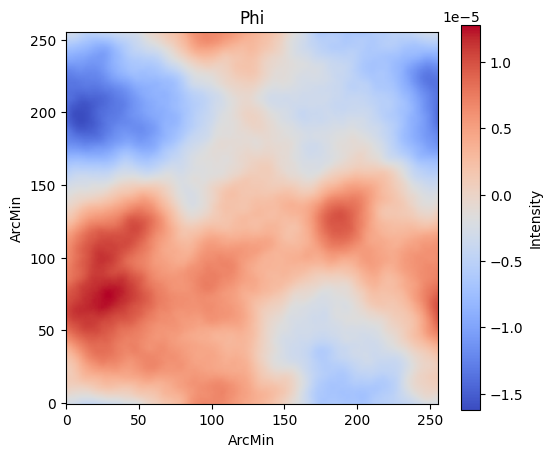

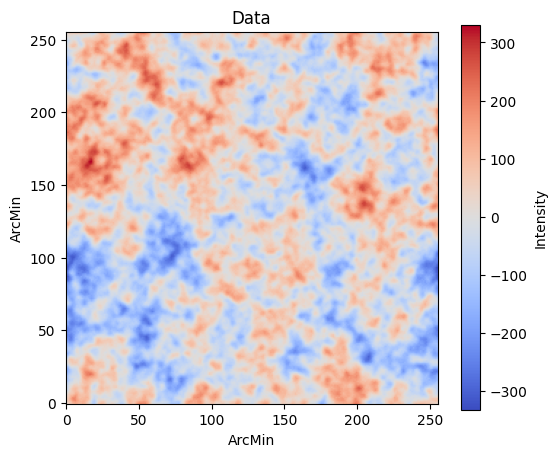

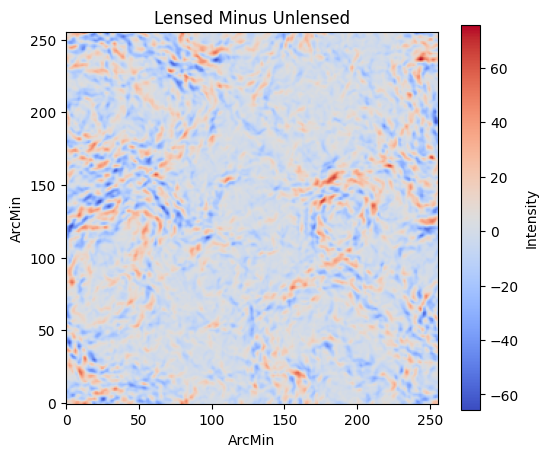

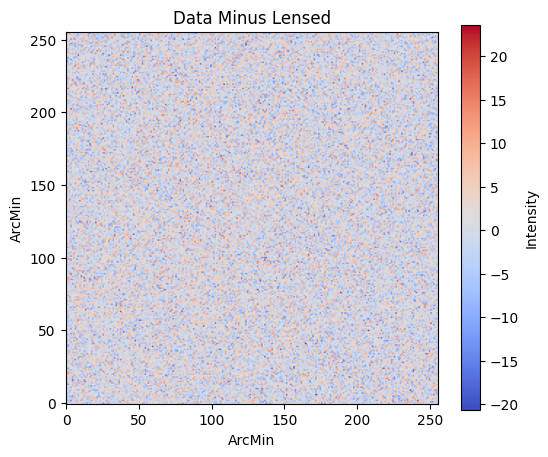

In [4]:
plot_heat_map(jfft.irfft2(unlensed_temp), "Unlensed Temp", "ArcMin", "ArcMin", "Intensity")
plot_heat_map(lensed_temp, "Lensed Temp", "ArcMin", "ArcMin", "Intensity")
plot_heat_map(jfft.irfft2(phi), "Phi", "ArcMin", "ArcMin", "Intensity")
plot_heat_map(jfft.irfft2(data), "Data", "ArcMin", "ArcMin", "Intensity")
plot_heat_map(lensed_temp - jfft.irfft2(unlensed_temp),  "Lensed Minus Unlensed", "ArcMin", "ArcMin", "Intensity")
plot_heat_map(jfft.irfft2(data) - lensed_temp, "Data Minus Lensed", "ArcMin", "ArcMin", "Intensity")

(256, 256)


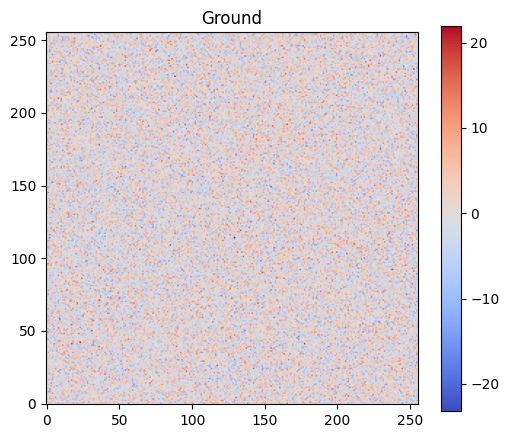

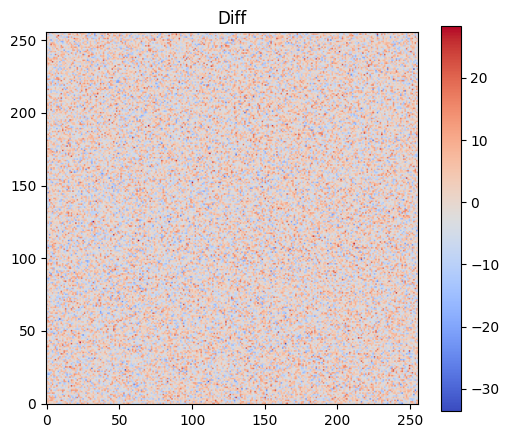

In [ ]:
data_minus_lensed_ground = jfft.irfft2(precision_load("/home/zane-blood/Desktop/cmb_lensing/data_minus_lensed.npz"))
print(data_minus_lensed_ground.shape)
plot_heat_map(data_minus_lensed_ground, "Ground", "", "", "")
plot_heat_map(data_minus_lensed_ground - (jfft.irfft2(data) - lensed_temp), "Diff", "", "", "")

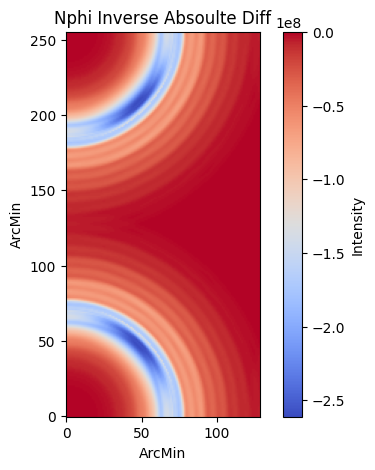

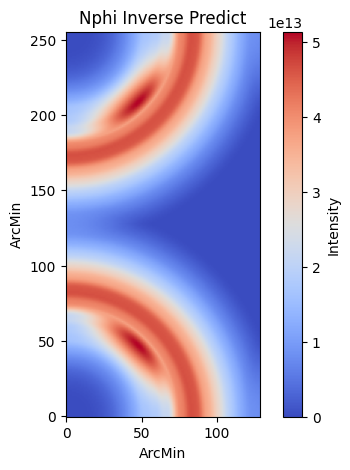

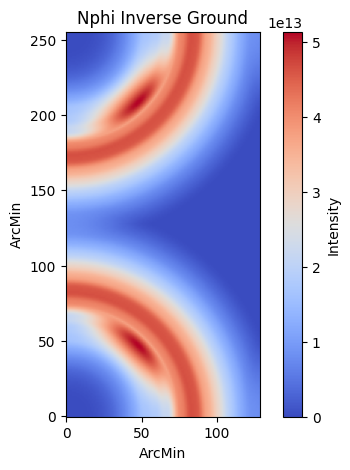

2.8702357443687877e-06


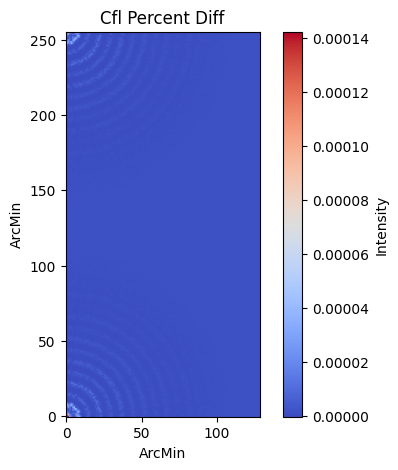

9.493736555318446e-05


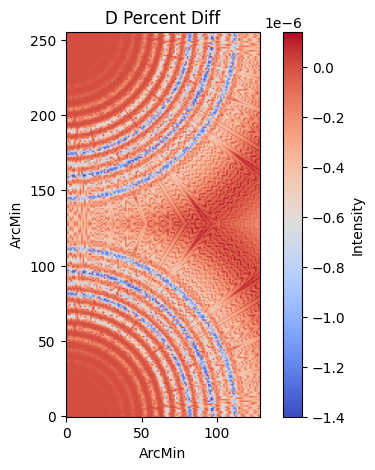

1.5688618289715513e-07


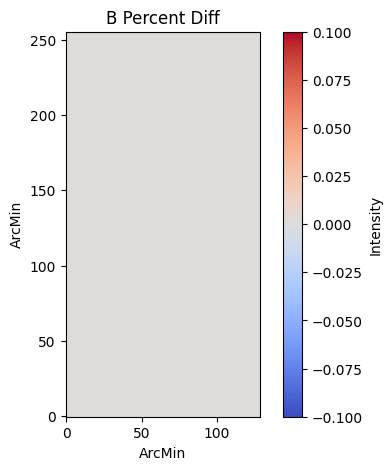

0.0


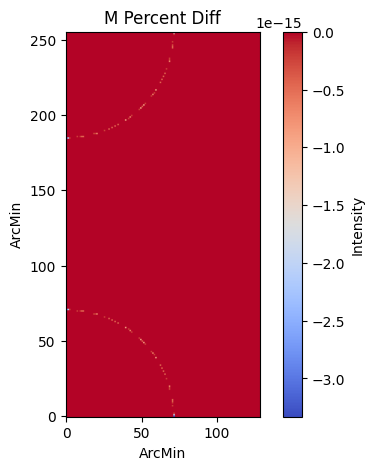

1.0618791533392335e-17


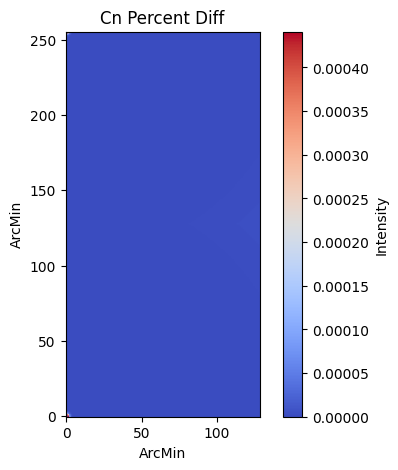

6.078705082729102e-05


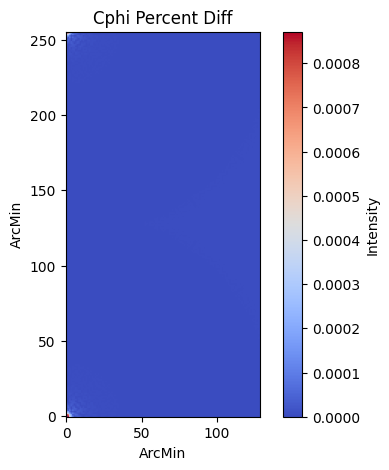

0.0008651345749518168


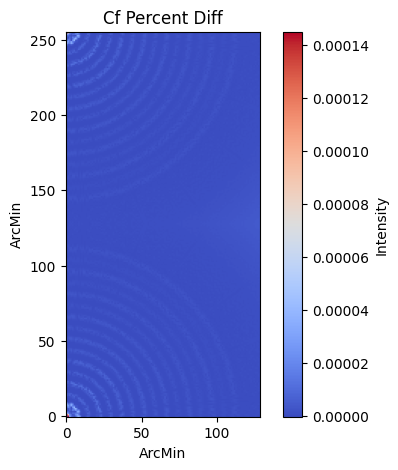

9.701262044474091e-05


In [5]:
cn_ground = reshape_diagonal(precision_load(os.getcwd() + "/julia_maximization_debug/cn_diagonal.npz"))
cphi_ground = reshape_diagonal(precision_load(os.getcwd() + "/julia_maximization_debug/cphi_diagonal.npz"))
cf_ground = reshape_diagonal(precision_load(os.getcwd() + "/julia_maximization_debug/cf_diagonal.npz"))
cfl_ground = reshape_diagonal(precision_load(os.getcwd() + "/julia_maximization_debug/cf_lensed_diagonal.npz"))
m_ground = reshape_diagonal(precision_load(os.getcwd() + "/julia_maximization_debug/m_diagonal.npz"))
b_ground = reshape_diagonal(precision_load(os.getcwd() + "/julia_maximization_debug/b_diagonal.npz"))
d_ground = reshape_diagonal(precision_load(os.getcwd() + "/julia_maximization_debug/d_diagonal.npz"))
nphi_inv_ground = np.nan_to_num(1 / reshape_diagonal(precision_load(os.getcwd() + "/julia_maximization_debug/nphi_diagonal.npz")), nan = 0, posinf = 0, neginf = 0)
nphi_inv = np.nan_to_num(1 / nphi, nan = 0, posinf = 0, neginf = 0)

plot_heat_map(nphi_inv - nphi_inv_ground, "Nphi Inverse Absoulte Diff", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.1, 0.1])
plot_heat_map(nphi_inv, "Nphi Inverse Predict", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.1, 0.1])
plot_heat_map(nphi_inv_ground, "Nphi Inverse Ground", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.1, 0.1])
print(percent_diff_2d(nphi_inv_ground, nphi_inv))

plot_heat_map(1 - np.nan_to_num(cfl/cfl_ground, nan = 1), "Cfl Percent Diff", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.01, 0.01])
print(percent_diff_2d(cfl_ground, cfl))

plot_heat_map(1 - d_matrix/d_ground, "D Percent Diff", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.1, 0.1])
print(percent_diff_2d(d_ground, d_matrix))

plot_heat_map(1 - np.nan_to_num(b/b_ground, nan = 1), "B Percent Diff", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.1, 0.1])
print(percent_diff_2d(b_ground, b))

plot_heat_map(1 - np.nan_to_num(m/m_ground, nan = 1), "M Percent Diff", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.1, 0.1])
print(percent_diff_2d(m_ground, m))

plot_heat_map(1 - np.nan_to_num(cn/cn_ground, nan = 1), "Cn Percent Diff", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.01, 0.01])
print(percent_diff_2d(cn_ground, cn))

plot_heat_map(1 - np.nan_to_num(cphi/cphi_ground, nan = 1), "Cphi Percent Diff", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.01, 0.01])
print(percent_diff_2d(cphi_ground, cphi))

plot_heat_map(1 - np.nan_to_num(cf/cf_ground, nan = 1), "Cf Percent Diff", "ArcMin", "ArcMin", "Intensity")#, clim = [-0.01, 0.01])
print(percent_diff_2d(cf_ground, cf))

In [ ]:
from functions import *
from simulate import *
ell = precision_load("/home/zane-blood/Desktop/cmb_lensing/julia_maximization_debug/ells.npz")
cl_pp_avg_julia = precision_load("/home/zane-blood/Desktop/cmb_lensing/julia_maximization_debug/cl_pp_avg_julia.npz")
cl_pp_avg_python = precision_load("/home/zane-blood/Desktop/cmb_lensing/julia_maximization_debug/cl_pp_avg_python.npz")
cl_tt_avg_julia = precision_load("/home/zane-blood/Desktop/cmb_lensing/julia_maximization_debug/cl_tt_avg_julia.npz")
cl_tt_avg_python = precision_load("/home/zane-blood/Desktop/cmb_lensing/julia_maximization_debug/cl_tt_avg_python.npz")
cl_dd_avg_julia = precision_load("/home/zane-blood/Desktop/cmb_lensing/julia_maximization_debug/cl_dd_avg_julia.npz")
cl_dd_avg_python = precision_load("/home/zane-blood/Desktop/cmb_lensing_julia_maximization_debug/cl_dd_avg_python.npz")
noise_cls_julia = precision_load("/home/zane-blood/Desktop/cmb_lensing/julia_maximization_debug/julia_noise_cls.npz")

In [ ]:
# TODO
# 1. Run descent with Python generated inputs and do the same for julia
# 2. Streamline the cross-spectra approach, i.e. build your own python auto-spectra method so all the 
#    analysis can be done in python, make some code that calls julia from python multiple times to get the julia auto-spectra data
# 3. Refactor in general
# 5. Start on polarization...
# 6. Make more unit tests: e.g. comparing simulation matrices, auto-spectra sigma (write these with julia-call syntax) but
#    don't necessarily both re-writing the others if they are still working.... Also binning method unit tests...

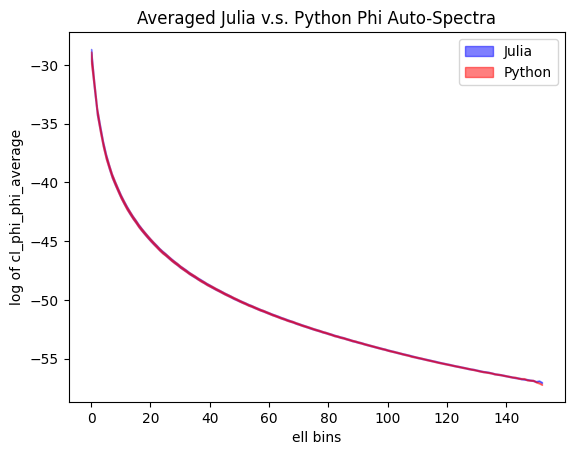

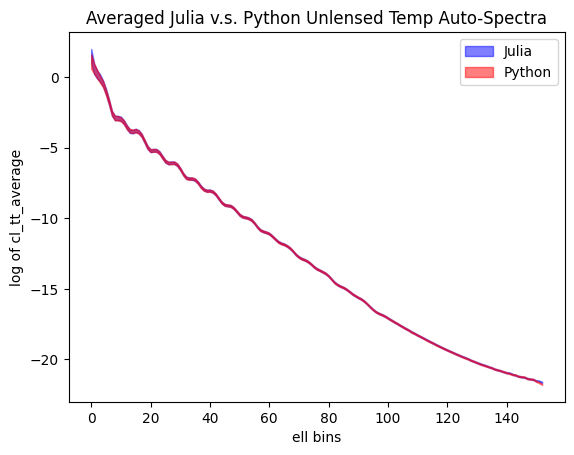

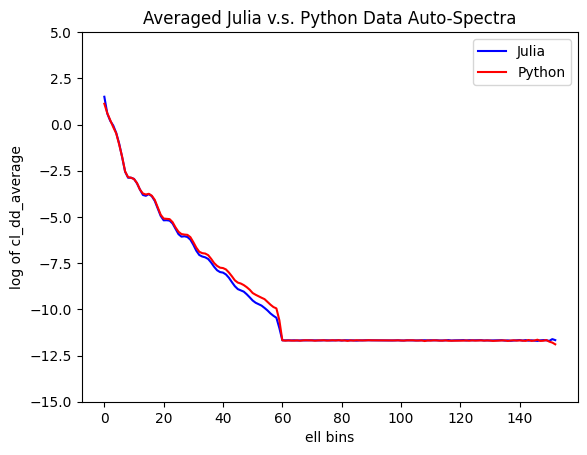

In [9]:
def f_sky(N, theta_pix):
    dx = np.deg2rad(theta_pix / 60)
    map_area = N**2 * dx**2 * (180 / np.pi)**2
    full_sky_area = 40_000
    return map_area/full_sky_area

def log_c_ell_variance(ell, f_sky, delta_l):
    result = 2/(delta_l * (2*ell + 1) * f_sky)
    return result

def log_c_ell_variance_with_noise(ell, f_sky, delta_l, cls, nls):
    result = 2 * (1 + nls / cls)**2 / (delta_l * (2*ell + 1) * f_sky)
    return result

def c_ell_variance_with_noise(ell, f_sky, delta_l, cls, nls):
    result = 2 * (nls + cls)**2 / (delta_l * (2*ell + 1) * f_sky)
    return result

F_SKY = f_sky(256, 2)
delta_l = 50
cl_pp_std = np.sqrt(log_c_ell_variance(ell, F_SKY, delta_l))
l_bins = jnp.arange(len(ell)) 

#-----------------------------------------------------------------
#PHI AUTO SPECTRA COMPARISON
#-----------------------------------------------------------------

#plt.plot(l_bins, jnp.log(cl_pp_avg_julia), label = "Julia", color = "blue")
plt.fill_between(l_bins, 
                 jnp.log(cl_pp_avg_julia) - cl_pp_std, 
                 jnp.log(cl_pp_avg_julia) + cl_pp_std, 
                 color="blue", 
                 label = "Julia",
                 alpha=0.5)
#plt.plot(l_bins, jnp.log(cl_pp_avg_python), label = "Python", color = "red")
plt.fill_between(l_bins, 
                 jnp.log(cl_pp_avg_python) - cl_pp_std, 
                 jnp.log(cl_pp_avg_python) + cl_pp_std, 
                 color="red", 
                 label = "Python",
                 alpha=0.5)
plt.legend()
plt.xlabel("ell bins")
#plt.xlim([145, 155])
plt.ylabel("log of cl_phi_phi_average")
plt.title("Averaged Julia v.s. Python Phi Auto-Spectra")
plt.show()

#---------------------------------------------------------------------------
#UNLENSED TEMP AUTO SPECTRA COMPARISON
#---------------------------------------------------------------------------

#plt.plot(l_bins, jnp.log(cl_tt_avg_julia), label = "Julia", color = "blue")
plt.fill_between(l_bins, 
                 jnp.log(cl_tt_avg_julia) - cl_pp_std, 
                 jnp.log(cl_tt_avg_julia) + cl_pp_std, 
                 color="blue", 
                 label = "Julia",
                 alpha=0.5)
#plt.plot(l_bins, jnp.log(cl_tt_avg_python), label = "Python", color = "red")
plt.fill_between(l_bins, 
                 jnp.log(cl_tt_avg_python) - cl_pp_std, 
                 jnp.log(cl_tt_avg_python) + cl_pp_std, 
                 color="red", 
                 label = "Python",
                 alpha=0.5)
plt.legend()
plt.xlabel("ell bins")
plt.ylabel("log of cl_tt_average")
#plt.xlim([0, 20])
plt.title("Averaged Julia v.s. Python Unlensed Temp Auto-Spectra")
plt.show()

#---------------------------------------------------------------------------
#DATA AUTO SPECTRA COMPARISON (i.e. Data = M * B * L * f + N)
#---------------------------------------------------------------------------
cl_dd_std = 1*np.sqrt(log_c_ell_variance_with_noise(ell, F_SKY, delta_l, cl_tt_avg_julia, noise_cls_julia))

plt.plot(l_bins, jnp.log(cl_dd_avg_julia), label = "Julia", color = "blue")
# plt.fill_between(l_bins, 
#                  jnp.log(cl_dd_avg_julia) - cl_dd_std, 
#                  jnp.log(cl_dd_avg_julia) + cl_dd_std, 
#                  color="blue", 
#                  label = "Julia",
#                  alpha=0.5)
plt.plot(l_bins, jnp.log(cl_dd_avg_python), label = "Python", color = "red")
# plt.fill_between(l_bins, 
#                  jnp.log(cl_dd_avg_python) - cl_dd_std, 
#                  jnp.log(cl_dd_avg_python) + cl_dd_std, 
#                  color="red", 
#                  label = "Python",
#                  alpha=0.5)
plt.legend()
plt.xlabel("ell bins")
plt.ylabel("log of cl_dd_average")
plt.ylim([-15, 5])
#plt.xlim([0, 60])
plt.title("Averaged Julia v.s. Python Data Auto-Spectra")
plt.show()

# cl_dd_std = np.sqrt(c_ell_variance_with_noise(ell, F_SKY, delta_l, cl_tt_avg_julia, noise_cls_julia))

# #plt.plot(l_bins, jnp.log(cl_dd_avg_julia), label = "Julia", color = "blue")
# plt.fill_between(l_bins, 
#                  (cl_dd_avg_julia) - cl_dd_std, 
#                  (cl_dd_avg_julia) + cl_dd_std, 
#                  color="blue", 
#                  label = "Julia",
#                  alpha=0.5)
# #plt.plot(l_bins, jnp.log(cl_dd_avg_python), label = "Python", color = "red")
# plt.fill_between(l_bins, 
#                  (cl_dd_avg_python) - cl_dd_std, 
#                  (cl_dd_avg_python) + cl_dd_std, 
#                  color="red", 
#                  label = "Python",
#                  alpha=0.5)
# plt.legend()
# plt.xlabel("ell bins")
# plt.ylabel("cl_dd_average")
# #plt.ylim([-5, 10])
# plt.ylim([-0.0001, 0.0001])
# plt.title("Julia v.s. Python Data Averaged Auto-Spectra")
# plt.show()